# TT-04 — Logistic Regression: Chẩn đoán nguy cơ bệnh tim

Dữ liệu: Heart Disease (UCI Cleveland / bản Kaggle).
Đặt file CSV tải về tại `data/heart.csv` trước khi chạy notebook này.

- UCI: https://archive.ics.uci.edu/dataset/45/heart+disease
- Kaggle: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              recall_score, precision_score, classification_report)

RANDOM_STATE = 42

## 1. Đọc dữ liệu và loại dòng trùng lặp

Bản Kaggle (1.025 dòng) là bản nhân bản từ 303 dòng gốc → phải `drop_duplicates()` trước khi chia train/test, nếu không sẽ rò rỉ dữ liệu.

In [7]:
df_raw = pd.read_csv('heart.csv')
n_before = len(df_raw)

df = df_raw.drop_duplicates().reset_index(drop=True)
n_after = len(df)

print(f"Số dòng trước khi loại trùng: {n_before}")
print(f"Số dòng sau khi loại trùng:  {n_after}")
print(f"Đã loại bỏ: {n_before - n_after} dòng trùng lặp")

df.head()

Số dòng trước khi loại trùng: 1025
Số dòng sau khi loại trùng:  302
Đã loại bỏ: 723 dòng trùng lặp


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Xác định biến phân loại

`cp`, `restecg`, `slope`, `thal`, `ca` là các mã số phân loại, không có thứ tự thật sự → cần one-hot encode, không được để nguyên dạng số.

In [ ]:
target_col = 'target'  #gán tên cột mục tiêu

categorical_cols = ['cp', 'restecg', 'slope', 'thal', 'ca', 'sex', 'fbs', 'exang']  #khai báo ds các cột chưa biến phân loại 
numeric_cols = [c for c in df.columns if c not in categorical_cols + [target_col]]

print("Biến phân loại:", categorical_cols)
print("Biến số:", numeric_cols)

for col in ['ca', 'thal']:   #duyệt qua hai cột 'ca' và 'thal' để in ra số lượng giá trị duy nhất trong mỗi cột
    print(f"\n{col}:\n{df[col].value_counts()}")

Biến phân loại: ['cp', 'restecg', 'slope', 'thal', 'ca', 'sex', 'fbs', 'exang']
Biến số: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

ca:
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

thal:
thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64


## 3. EDA nhanh

In [ ]:
import os
os.makedirs('reports', exist_ok=True)  #tạo thư mục
os.makedirs('models', exist_ok=True)

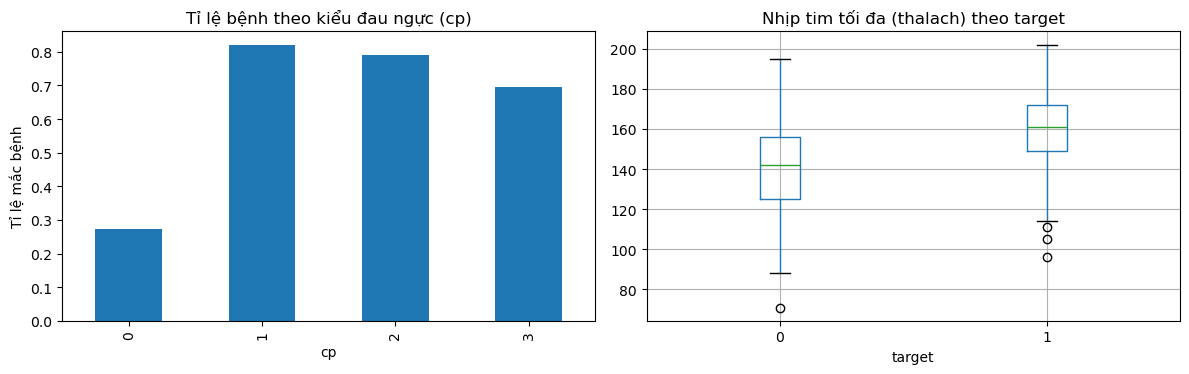

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('cp')[target_col].mean().plot(kind='bar', ax=axes[0], title='Tỉ lệ bệnh theo kiểu đau ngực (cp)')
axes[0].set_ylabel('Tỉ lệ mắc bệnh')

df.boxplot(column='thalach', by=target_col, ax=axes[1])
axes[1].set_title('Nhịp tim tối đa (thalach) theo target')      #đặt tên cho biểu đồ
plt.suptitle('')
plt.tight_layout()
plt.savefig('reports/eda.png', dpi=120)
plt.show()

## 4. Chia train/test và xây Pipeline

Pipeline: OneHotEncoder cho biến phân loại + StandardScaler cho biến số, sau đó LogisticRegression.

In [ ]:
X = df.drop(columns=[target_col])  #Dòng này tạo ra biến X chứa tất cả các cột thông tin, ngoại trừ cột mục tiêu (target_col)
y = df[target_col]  #Dòng này tạo ra biến y chỉ chứa duy nhất cột mục tiêu 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
          stratify=y, #đảm bảo tỉ lệ người bệnh và khỏe ở cả 2 tập giống nhau
          random_state=RANDOM_STATE)  #giúp cố định cách chia dữ liệu, để mỗi lần chạy sẽ cho ra kết quả giống nhau

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numeric_cols),
])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (241, 13), Test: (61, 13)


## 5. Baseline (DummyClassifier)

In [13]:
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
print(classification_report(y_test, baseline.predict(X_test)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        28
           1       0.54      1.00      0.70        33

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61



c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 6. Huấn luyện Logistic Regression và bảng Odds Ratio

In [14]:
logreg_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegressionCV(Cs=10, cv=5, penalty='l2',
                                    scoring='recall', max_iter=2000,
                                    random_state=RANDOM_STATE)),
])
logreg_pipeline.fit(X_train, y_train)

feature_names = logreg_pipeline.named_steps['preprocess'].get_feature_names_out()
coefs = logreg_pipeline.named_steps['model'].coef_[0]

odds_ratio = pd.DataFrame({
    'dac_trung': feature_names,
    'he_so_w': coefs,
    'odds_ratio': np.exp(coefs),
}).sort_values('odds_ratio', ascending=False)

odds_ratio.to_csv('reports/odds_ratio.csv', index=False)
odds_ratio

,dac_trung,he_so_w,odds_ratio
20,num__thalach,0.005141,1.005154
8,cat__thal_2,0.003119,1.003124
6,cat__slope_2,0.002016,1.002018
1,cat__cp_2,0.001975,1.001977
3,cat__restecg_1,0.001014,1.001014
0,cat__cp_1,0.000971,1.000972
2,cat__cp_3,0.000422,1.000422
13,cat__ca_4,0.000082,1.000082
4,cat__restecg_2,-0.000116,0.999884
15,cat__fbs_1,-0.000192,0.999808


## 7. So sánh L1 (Lasso) và L2 (Ridge)

`C = 1/λ` → C nhỏ nghĩa là phạt mạnh (ngược trực giác).

In [15]:
def fit_and_score(penalty, solver):
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', LogisticRegressionCV(Cs=10, cv=5, penalty=penalty, solver=solver,
                                        scoring='recall', max_iter=2000,
                                        random_state=RANDOM_STATE)),
    ])
    pipe.fit(X_train, y_train)
    auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    n_zero = np.sum(np.isclose(pipe.named_steps['model'].coef_[0], 0))
    return pipe, auc, n_zero

pipe_l2, auc_l2, zero_l2 = fit_and_score('l2', 'lbfgs')
pipe_l1, auc_l1, zero_l1 = fit_and_score('l1', 'saga')

print(f"L2 (Ridge): AUC = {auc_l2:.3f}, số hệ số = 0: {zero_l2}")
print(f"L1 (Lasso): AUC = {auc_l1:.3f}, số hệ số = 0: {zero_l1}")

L2 (Ridge): AUC = 0.902, số hệ số = 0: 0
L1 (Lasso): AUC = 0.500, số hệ số = 0: 22


## 8. Đường ROC và Precision-Recall

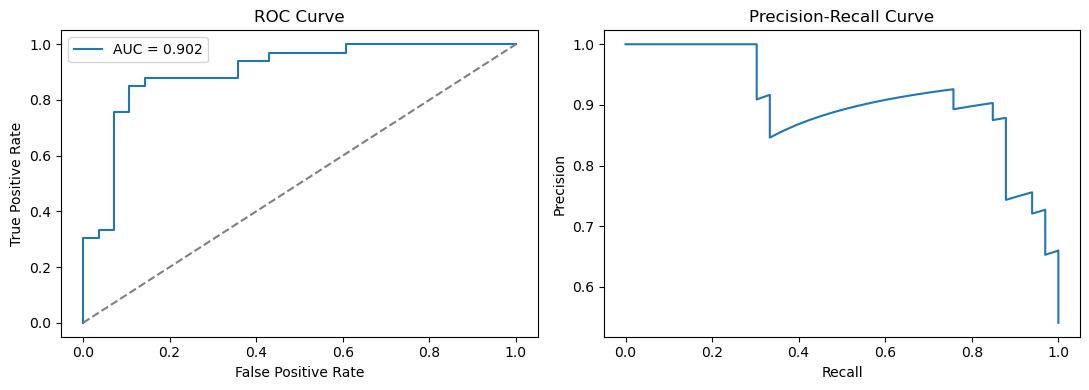

In [16]:
y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, roc_thr = roc_curve(y_test, y_proba)
precision, recall, pr_thr = precision_recall_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()

axes[1].plot(recall, precision)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('reports/roc_pr_curve.png', dpi=120)
plt.show()

## 9. Chọn ngưỡng đạt recall ≥ 0,90

In [17]:
target_recall = 0.90
valid = recall >= target_recall
# pr_thr has one fewer element than precision/recall; align indices
best_idx = np.where(valid[:-1])[0][-1]  # highest threshold that still meets recall

chosen_threshold = pr_thr[best_idx]
chosen_precision = precision[best_idx]
chosen_recall = recall[best_idx]

print(f"Ngưỡng chọn: {chosen_threshold:.3f}")
print(f"Recall đạt được: {chosen_recall:.3f}")
print(f"Precision tương ứng: {chosen_precision:.3f}")

y_pred_thr = (y_proba >= chosen_threshold).astype(int)
print(classification_report(y_test, y_pred_thr))

Ngưỡng chọn: 0.541
Recall đạt được: 0.909
Precision tương ứng: 0.750
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



## 10. Kiểm tra đa cộng tuyến (VIF)

Chỉ tính VIF trên các biến số (đã chuẩn hoá), không tính trên biến one-hot.

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num = StandardScaler().fit_transform(df[numeric_cols])
vif = pd.DataFrame({
    'bien': numeric_cols,
    'VIF': [variance_inflation_factor(X_num, i) for i in range(len(numeric_cols))]
}).sort_values('VIF', ascending=False)

vif.to_csv('reports/vif_table.csv', index=False)
print(vif)
print("\nBiến có VIF > 10 (đáng lo ngại):", list(vif.loc[vif['VIF'] > 10, 'bien']))

       bien       VIF
0       age  1.345233
3   thalach  1.322545
4   oldpeak  1.176598
1  trestbps  1.131176
2      chol  1.057566

Biến có VIF > 10 (đáng lo ngại): []


## 11. So sánh với SVM và Random Forest

In [19]:
models = {
    'LogisticRegression': logreg_pipeline,
    'SVM': Pipeline([('preprocess', preprocess),
                      ('model', SVC(probability=True, random_state=RANDOM_STATE))]),
    'RandomForest': Pipeline([('preprocess', preprocess),
                               ('model', RandomForestClassifier(random_state=RANDOM_STATE))]),
}

results = []
for name, model in models.items():
    if name != 'LogisticRegression':
        model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        'model': name,
        'roc_auc': roc_auc_score(y_test, proba),
        'recall_at_0.5': recall_score(y_test, (proba >= 0.5).astype(int)),
        'precision_at_0.5': precision_score(y_test, (proba >= 0.5).astype(int)),
    })

pd.DataFrame(results)

,model,roc_auc,recall_at_0.5,precision_at_0.5
0,LogisticRegression,0.901515,1.000000,0.540984
1,SVM,0.877706,0.757576,0.862069
2,RandomForest,0.887446,0.787879,0.812500


## 12. Giải thích cho một bệnh nhân cụ thể

In [20]:
patient = X_test.iloc[[0]]
patient_proba = logreg_pipeline.predict_proba(patient)[0, 1]

print(f"Xác suất mô hình dự đoán nguy cơ bệnh tim: {patient_proba:.1%}")
print(f"Nhãn thực tế: {'Có bệnh' if y_test.iloc[0] == 1 else 'Không bệnh'}")
print()
print("3 yếu tố nguy cơ có odds ratio cao nhất trong mô hình:")
print(odds_ratio.head(3)[['dac_trung', 'odds_ratio']])
print()
print("Diễn giải mẫu: 'Dựa trên các chỉ số đo được (đau ngực kiểu ..., "
      "nhịp tim tối đa ..., ...), mô hình ước tính xác suất mắc bệnh tim là "
      f"{patient_proba:.0%}. Đây là công cụ hỗ trợ tham khảo, quyết định "
      "chẩn đoán cuối cùng vẫn thuộc về bác sĩ.'")

Xác suất mô hình dự đoán nguy cơ bệnh tim: 54.1%
Nhãn thực tế: Không bệnh

3 yếu tố nguy cơ có odds ratio cao nhất trong mô hình:
       dac_trung  odds_ratio
20  num__thalach    1.005154
8    cat__thal_2    1.003124
6   cat__slope_2    1.002018

Diễn giải mẫu: 'Dựa trên các chỉ số đo được (đau ngực kiểu ..., nhịp tim tối đa ..., ...), mô hình ước tính xác suất mắc bệnh tim là 54%. Đây là công cụ hỗ trợ tham khảo, quyết định chẩn đoán cuối cùng vẫn thuộc về bác sĩ.'
